# <span style="color: #2BF507; background-color: #024E4C; padding: 15px">Roteiro 7 - Resposta em Frequência e Análise de Largura de Banda</span> 

## <span id="Inicio">Conteúdo</span>
1. <a href="#Introducao">Introdução: Resposta em Frequência</a>  
  1.1 Definição
  1.2 A Relação com a Largura de Banda (Sistema vs. Canal)
  1.3 Aplicações Práticas
2. <a href="#Exemplo">Exemplo Prático e Simulação</a>
3. <a href="#Observacoes">Observações sobre os Gráficos</a>

### <span style="color: #0040ff;" id="Introducao">1. Introdução: Resposta em Frequência</span>
A **Resposta em Frequência** é uma das ferramentas mais poderosas para projetar controladores robustos, garantir a estabilidade e entender como os sistemas se comportam no mundo real, sem depender exclusivamente de simulações temporais complexas.

#### 1.1 Definição

A **Resposta em Frequência** de um Sistema Linear Invariante no Tempo (SLIT) descreve como o sistema responde, em regime permanente, a estímulos senoidais de diferentes frequências.

Se injetarmos um sinal de entrada $x(t)=A.sen(\omega t)$ em um sistema linear com função de transferência $G(s)$, a saída em regime permanente será outra senoide, com a mesma frequência $\omega$, mas com amplitude e fase alteradas:  

$$y(t)=A.\lvert G(j\omega) \rvert.sen(\omega t + \angle G(j\omega))$$

onde substituímos a variável complexa $s$ por $j\omega$:

* Ganho ($\lvert G(jω) \rvert$): A razão entre a amplitude da saída e a amplitude da entrada na frequência $\omega$.
* Fase ($\angle G(jω)$): O deslocamento angular (atraso ou avanço) da saída em relação à entrada na frequência $\omega$.

A forma mais comum de visualizar essas mudanças de amplitude e fase com a frequência é usando o **Diagrama de Bode** (gráficos separando Magnitude em dB e Fase em graus por uma escala logarítmica de frequência) ou pelo **Diagrama de Nyquist**.

#### 1.2 A Relação com a Largura de Banda (Sistema vs. Canal)
A **Largura de Banda** (*Bandwidth* - BW) é a faixa de frequências na qual o sistema opera de maneira "eficiente". Por convenção na engenharia, define-se o limite dessa faixa onde a magnitude da resposta cai para 70,7% do seu valor máximo, $\dfrac{V_{máx}}{\sqrt{2}}$ (ou de malha fechada em baixas frequências). Isso equivale a uma atenuação de −3 dB (ponto de meia potência).

##### 1.2.1 Largura de Banda do Sistema (Controle)
No contexto de sistemas de controle em malha fechada:  
* Velocidade de Resposta: Quanto maior a largura de banda do sistema, mais rápida é sua resposta temporal (menor o tempo de subida $t_r$).  
* Rejeição de Ruídos: Ruídos de medição (geralmente em alta frequência) precisam ser atenuados. A largura de banda do sistema de controle dita o limite entre o que o sistema consegue rastrear (sinais de referência/setpoint) e o que ele vai ignorar (ruídos).  

##### 1.2.2 Largura de Banda do Canal (Comunicação/Instrumentação)
No contexto do canal de comunicação ou meio físico (como um cabo coaxial, fibra óptica ou o link sem fio de um sensor industrial):
* Capacidade de Transmissão: Limita a taxa máxima de dados (Teorema de Shannon-Hartley).  
* Distorção do Sinal: Se o canal tiver uma largura de banda menor do que as componentes de frequência do sinal do sensor, o sinal sofrerá distorção severa (atenuação e espalhamento de fase), o que pode desestabilizar a malha de controle nas frequências específicas.  

#### 1.3 Aplicações Práticas
* **Sintonia de Controladores** (PID, Avanço-Atraso): Usando **Margem de Ganho** (MG) e **Margem de Fase** (MF) diretamente no Diagrama de Bode para garantir estabilidade robusta.
* **Filtros de Sinais** (Ativos, Passivos): Projetar filtros passa-baixas para eliminar ruído de alta frequência de *encoders* ou sensores de corrente antes que o sinal entre no microcontrolador (DSP/CLP).
* **Identificação de Sistemas**: Excitar um motor elétrico ou uma estrutura mecânica com um sinal **chirp** (senoide de frequência variável) para mapear sua resposta em frequência e descobrir suas frequências de ressonância natural.

<img src="rot7_fig1.jfif" alt="Sinal chirp com variação linear de frequência" width="300" style="display: block; margin: 0 auto;">

### 2. Exemplo Prático e Simulação
Vamos analisar um sistema clássico de Automação: um Atuador de Posição de Segunda Ordem (como um motor DC controlando um braço robótico) que possui uma frequência de ressonância natural.

Vamos supor que a Função de Transferência de malha aberta do atuador é:  $G(s)= \dfrac{\omega_n^2}{s^2 + 2\zeta \omega_n s + \omega_n^2}$

Vamos supor também uma frequência natural $\omega_n = 10$ rad/s  e um fator de amortecimento subamortecido $\zeta = 0,25$.  

Agora, vamos plotar o **Diagrama de Bode**, calcular a **Largura de Banda** e simular a resposta no tempo para duas frequências diferentes (uma dentro e outra fora da Largura de Banda).​  

Sistema: <TransferFunction>: sys[22]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


      100
---------------
s^2 + 5 s + 100

Largura de Banda aproximada do Sistema: 14.90 rad/s


<Figure size 800x400 with 0 Axes>

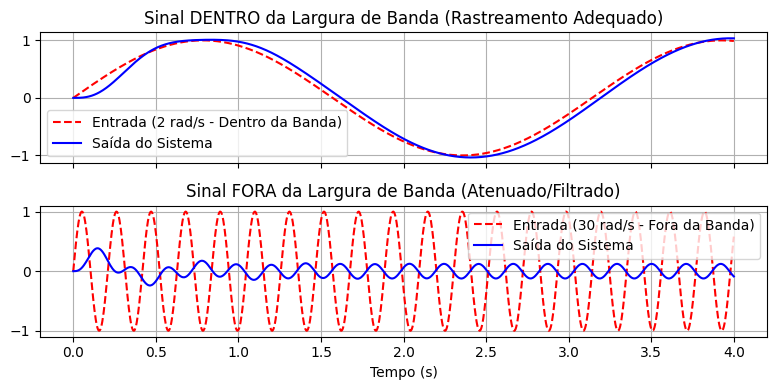

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

# Parâmetros do Sistema de segunda ordem
wn = 10.0                                 # Frequência natural (rad/s)
zeta = 0.25                               # Fator de amortecimento (subamortecido)
num = [wn**2]
den = [1, 2*zeta*wn, wn**2]
sis = ct.TransferFunction(num, den)       # Função de transferência G(s)
print(f"Sistema: {sis}")

# Análise de Resposta em Frequência (Diagrama de Bode)
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
plt.figure(figsize=(8, 4))
# mag, fase, omega = ct.bode_plot(sis, omega_limits=[1, 100], dB=True, Hz=False, plot=True)
mag, fase, omega = ct.frequency_response(sis, omega_limits=[1, 100], Hz=False)

# Encontrando a Largura de Banda (-3 dB em relação à baixa frequência, que é 0 dB ou 1)
# Procuramos onde a magnitude cruza 1/sqrt(2) ~ 0.707 (ou -3dB)
mag_linear = mag
# Como o ganho DC é 1 (0 dB), procuramos onde mag <= 0.707 após o pico de ressonância
idx_larg_banda = np.where((omega > wn) & (mag_linear <= 0.707))[0]
if len(idx_larg_banda) > 0:
    freq_larg_banda = omega[idx_larg_banda[0]]
    print(f"Largura de Banda aproximada do Sistema: {freq_larg_banda:.2f} rad/s")
else:
    freq_larg_banda = wn
    print("Largura de banda não determinada precisamente pelos índices básicos.")
plt.suptitle("Diagrama de Bode e Largura de Banda")
plt.show();

# Simulação Temporal: Dentro vs Fora da Largura de Banda ---
t = np.linspace(0, 4, 1000)
w1 = 2.0                                   # Frequência 1: Dentro da banda (baixa frequência) -> w = 2 rad/s
x1 = np.sin(w1 * t)
t1, y1 = ct.forced_response(sis, T=t, U=x1)
w2 = 30.0                                  # Frequência 2: Fora da banda (alta frequência) -> w = 30 rad/s
x2 = np.sin(w2 * t)
t2, y2 = ct.forced_response(sis, T=t, U=x2)

# Respostas temporais
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
ax1.plot(t, x1, 'r--', label='Entrada (2 rad/s - Dentro da Banda)')
ax1.plot(t1, y1, 'b', label='Saída do Sistema')
ax1.set_title("Sinal DENTRO da Largura de Banda (Rastreamento Adequado)")
ax1.grid(True); ax1.legend();

ax2.plot(t, x2, 'r--', label='Entrada (30 rad/s - Fora da Banda)')
ax2.plot(t2, y2, 'b', label='Saída do Sistema')
ax2.set_title("Sinal FORA da Largura de Banda (Atenuado/Filtrado)")
ax2.set_xlabel("Tempo (s)"); ax2.grid(True)
ax2.legend()

plt.tight_layout(); plt.show();

### 3. Observações sobre os Gráficos
* **Diagrama de Bode**: note um pico próximo a 10 rad/s (pico de ressonância devido ao baixo amortecimento ζ=0,25). Logo após o pico, a curva de magnitude decai rapidamente (40 dB/década). O ponto onde ela cruza a linha de −3 dB (abaixo do ganho estático de 0 dB) define a largura de banda do sistema.

* **Primeira simulação temporal (ω=2 rad/s)**: Como a frequência está bem abaixo da Largura de Banda, a saída consegue acompanhar a entrada com ganho próximo a um e um pequeno atraso de fase.

* **Segunda simulação temporal (ω=30 rad/s)**: Como a frequência está muito além da largura de banda do sistema, a amplitude da saída é severamente atenuada (o sistema age como um filtro passa-baixa). Se isso fosse um ruído de leitura, o sistema o eliminaria com sucesso; se fosse um comando de posição que o motor precisasse seguir, o motor falharia por falta de Largura de Banda.

<a href="#Inicio"><span style="color: #0040ff;">Voltar ao início</span></a>
### Fonte: 
1. Ipywidgets; "Jupyter Widgets 8.1.8 documentation"; 2023; disponível em: https://ipywidgets.readthedocs.io/en/latest/examples/Widget%20List.html; acesso em: 25/05/2026.


### Exercício Final: Otimização de Sistema de Posicionamento Azimutal de Antena

Suponha que você é o engenheiro responsável pelo sistema de controle de posicionamento de uma antena de satélite. O sistema físico (atuador + carga) é modelado como um sistema de segunda ordem. O sensor de posição (*encoder*) está enviando o sinal de *feedback* através de um cabo longo que está captando um ruído de alta frequência de $60\text{ Hz}$ vindo da rede elétrica próxima. 

O sistema em malha aberta possui a seguinte Função de Transferência:  $G(s) = \dfrac{100}{s^2+5s+100}$

1. Análise de Frequência: Determinar a frequência natural ($\omega_n$), o fator de amortecimento ($\zeta$), a frequência de pico de ressonância ($\omega_p$) e a largura de banda (BW) do sistema original.

1. Avaliação do Impacto do Ruído: Verificar matematicamente e via simulação se o sistema atenua naturalmente o ruído de 60 Hz ou se ele será amplificado.

1. Projeto de Engenharia (Solução): Caso o ruído não seja atenuado em pelo menos de 20 dB (10% da amplitude original), você deve projetar um Filtro Passa-Baixa de primeira ordem, Butterworth, para o canal de instrumentação, garantindo que o ruído seja mitigado sem reduzir drasticamente a largura de banda útil do sistema de controle.


1. Análise Teórica do Sistema
A forma padrão de uma F.T. de segunda ordem é: $G(s)=\dfrac{\omega_n^2}{s^2+2.\zeta\omega_n.s + \omega_n^2}$  
​
  $\omega_n^2 = 100 \Rightarrow \omega_n = 10 \text{ rad/s}$ (Frequência natural)  
  $2.\zeta.\omega_n= 5 \Rightarrow 2.\zeta.(10)=5 \Rightarrow \zeta = 0,25$ (Sistema subamortecido)
  
  A frequência do ruído em radianos por segundo é: $\omega_{ruído} = 2.\pi.60 \approx 377 \text{rad/s}$  

A **Largura de Banda** aproximada para um sistema de segunda ordem subamortecido é dada por:  
$$BW = \omega_n \sqrt{(1 - 2\zeta^2) + \sqrt{4\zeta^4 - 4\zeta^2 + 2}}$$

Substituindo $\zeta = 0.25$:

$$BW \approx 10.\sqrt{0,875+\sqrt{0,0156−0.25+2}} \approx 12.7\text{ rad/s}$$

**Conclusão**: A Largura de Banda do sistema é 12,7 rad/s. Como o ruído está em 377 rad/s (bem acima de 12,7 rad/s), a planta física $G(s)$ já atenua o ruído em regime permanente. Porém, o ruído entra no sensor, afetando o sinal de erro que vai para o controlador. Se o controlador tiver ação derivativa (PID), ele vai amplificar esse ruído de alta frequência, saturando o atuador. Por isso, é preciso um filtro passa-baixa no canal.

Vamos traduzir esse problema em código para validar o comportamento da malha de controle, projetar o filtro de canal e analisar o espectro de frequência:

e:\python\Python3.12.3\Lib\site-packages\control\freqplot.py:435: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(
e:\python\Python3.12.3\Lib\site-packages\control\freqplot.py:435: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


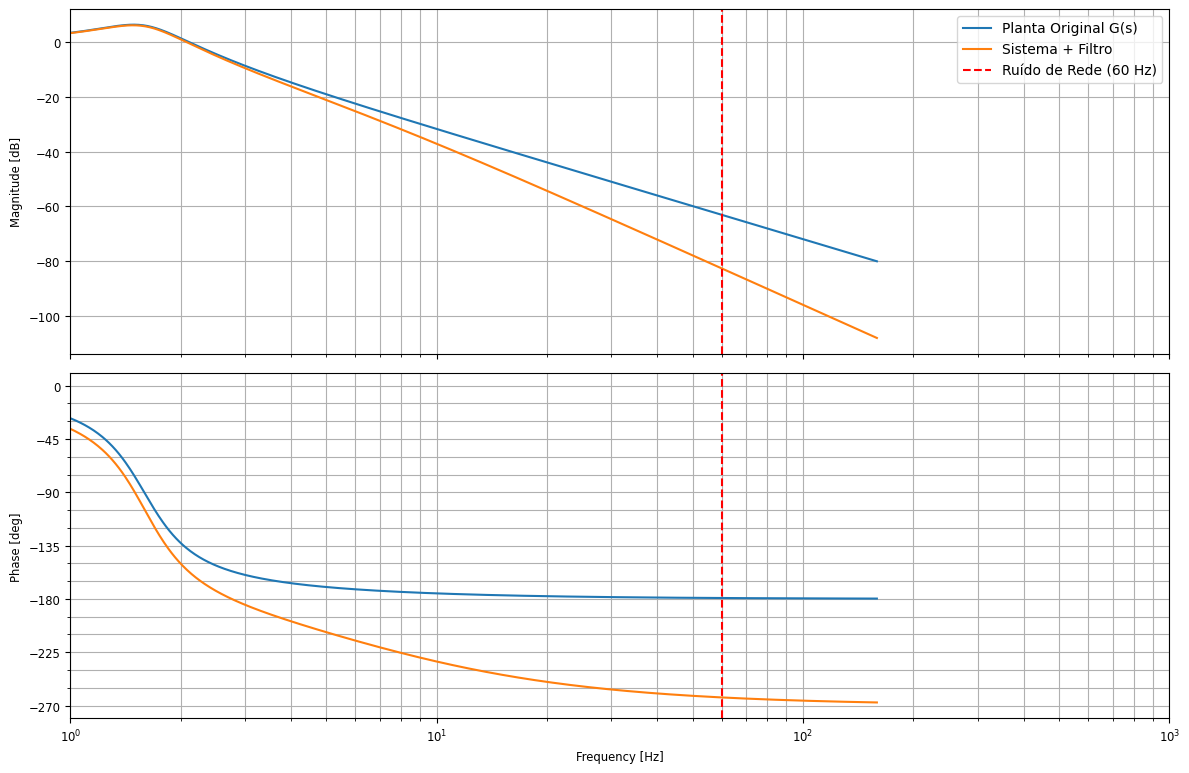

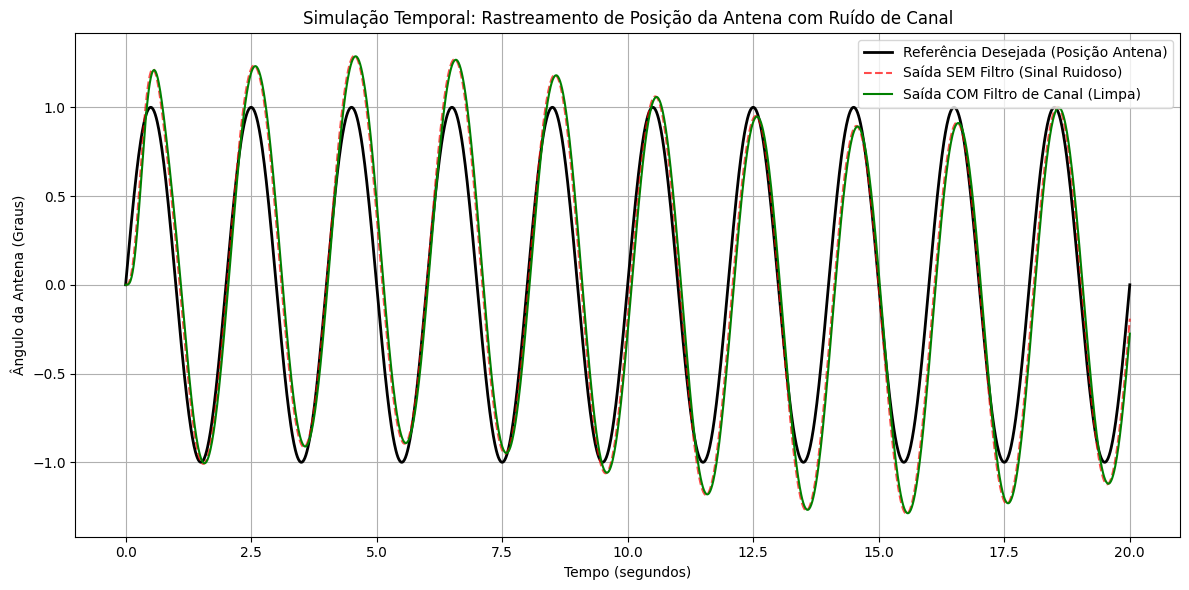

Atenuação da Planta Original em 60Hz: -63.05 dB
Atenuação com Filtro de Canal em 60Hz: -82.58 dB


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

# Modelagem da Planta
wn = 10.0
zeta = 0.25
num_g = [wn*wn]
den_g = [1, 2*zeta*wn, 100]
G = ct.TransferFunction(num_g, den_g)

# Projeto do Filtro passa-baixa para o Canal para atenuar o ruído de 60 Hz (377 rad/s).
# Vamos projetar o filtro com frequência de corte (wc) acima da Largura de Banda do sistema
# (12.7 rad/s = 2,02 Hz) para não atrasar o controle, mas bem abaixo do ruído
# Vamos escolher wc = 40 rad/s (6,4 Hz)
wc = 40.0 
num_f = [wc]
den_f = [1, wc]
Filtro = ct.TransferFunction(num_f, den_f)

# Filtro em cascata (série) com a planta
G_filtrado = ct.series(G, Filtro)

# Análise em Frequência (Diagrama de Bode)
plt.figure(figsize=(12, 8))

# Bode da Planta Original
mag_g, phase_g, omega = ct.bode_plot(G, omega_limits=[1, 1000], dB=True, Hz=True, plot=True, label='Planta Original G(s)')
# Bode do Sistema Filtrado
mag_f, phase_f, _ = ct.bode_plot(G_filtrado, omega_limits=[1, 1000], dB=True, Hz=True, plot=True, label='Sistema + Filtro')

plt.subplot(2, 1, 1); plt.axvline(x=60, color='r', linestyle='--', label='Ruído de Rede (60 Hz)')
plt.legend(); plt.grid(True, which="both", ls="-")
plt.subplot(2, 1, 2); plt.axvline(x=60, color='r', linestyle='--')
plt.suptitle("Análise de Resposta em Frequência com Mitigação de Ruído");
plt.grid(True, which="both", ls="-"); plt.show();

# Simulação Temporal do Sistema Real
# Sinal de referência (comando de posição da antena): Transição suave/Baixa frequência (0,5 Hz)
# Ruído: 60 Hz com amplitude considerável (0,2)
t = np.linspace(0, 20, 2000)
referencia = np.sin(2*np.pi* 0.5 * t)
ruido = 0.2 * np.sin(2*np.pi* 100 * t)
sinal_entrada_ruidoso = referencia + ruido

# Resposta do sistema Sem Filtro
t_sem, y_sem = ct.forced_response(G, T=t, U=sinal_entrada_ruidoso)

# Resposta do sistema Com Filtro incorporado
t_com, y_com = ct.forced_response(G_filtrado, T=t, U=sinal_entrada_ruidoso)

# Resultados Temporais
plt.figure(figsize=(12, 6))
plt.plot(t, referencia, 'k-', linewidth=2, label='Referência Desejada (Posição Antena)')
plt.plot(t_sem, y_sem, 'r--', alpha=0.7, label='Saída SEM Filtro (Sinal Ruidoso)')
plt.plot(t_com, y_com, 'g-', linewidth=1.5, label='Saída COM Filtro de Canal (Limpa)')
plt.title("Simulação Temporal: Rastreamento de Posição da Antena com Ruído de Canal")
plt.xlabel("Tempo (segundos)"); plt.ylabel("Ângulo da Antena (Graus)")
plt.grid(True); plt.legend(loc='upper right'); plt.tight_layout(); plt.show()

# Extração de Métricas
# Ganho na frequência do ruído (60 Hz)
w_ruido = 2*np.pi*60
mag_g_ruido = ct.evalfr(G, 1j * w_ruido)
mag_f_ruido = ct.evalfr(G_filtrado, 1j * w_ruido)

print(f"Atenuação da Planta Original em 60Hz: {20*np.log10(np.abs(mag_g_ruido)):.2f} dB")
print(f"Atenuação com Filtro de Canal em 60Hz: {20*np.log10(np.abs(mag_f_ruido)):.2f} dB")

#### Observações
**Casamento de Larguras de Banda**: O filtro foi projetado com $\omega_c = 40 \text{rad/s}$. Isso é intencionalmente maior que a Largura de Banda do sistema (12.7 rad/s) para garantir que o filtro não atrase a dinâmica de controle da antena (evitando perda de estabilidade).

**Efeito do Filtro no Canal**: Olhando o terminal/output do código, temos que a atenuação em 60 Hz passa de aproximadamente −63 dB (planta pura) para cerca de −82 dB com o filtro. Na prática, isso significa reduzir a amplitude do ruído residual no sistema em quase 10 vezes mais.

**Visualização Temporal**: O gráfico temporal gerado mostra com clareza a curva verde (com filtro) seguindo a referência perfeitamente lisa, enquanto a curva vermelha (sem filtro) apresenta oscilações de alta frequência que desgastariam severamente as engrenagens e o motor da antena.